# Mekong Delta Hydraulic Analysis - Vinh Chau and Nha Mat
Input of Tung's data June 2025, June 2026. This file is for processing data and creating dataframe, so that the dataframe can be used for analysis of data. 

# Setup of dataframe

In [100]:
#import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.signal import welch

In [101]:
#collect data from txt files and convert to pandas dataframe

def read_data(file_path):

    df = pd.read_csv(file_path, sep="\t", comment="#")

    date_col = [col for col in df.columns if col.lower() == "date_time"][0]
    df = df.rename(columns={date_col: "Date_time"})

    df["Date_time"] = pd.to_datetime(
        df["Date_time"],
        format="%d/%m/%Y %H:%M"
    )

    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


base_path = Path("/Users/ingeb/repositories/mekong/hydrological_study")

files = {
    2025: {
        "ssc_nearshore": "2025_Data_SSC_Nearshore.txt",
        "ssc_offshore": "2025_Data_SSC_Offshore.txt",
        "water_depth": "2025_Data_WaterDepth.txt",
        "adcp_flow": "2025_Data_Wave_ADCP_TXVC13_Flow.txt",
        "adcp_wave": "2025_Data_Wave_ADCP_TXVC13_Wave.txt",
        "twr_wave": "2025_Data_Wave_TWR2050R.txt",
        "buoy_wave": "2025_Data_Wave_WB2026.txt"
    },

    2026: {
        "water_depth": "2026_Data_WaterDepth.txt",
        "twr_wave": "2026_Data_Wave_TWR2050R.txt",
        "buoy_wave": "2026_Data_Wave_WB2026.txt"
    }
}


data = {
    year: {
        name: read_data(base_path / f"{year}_data" / filename)
        for name, filename in datasets.items()
    }
    for year, datasets in files.items()
}

In [102]:
#check if dataframes are loaded correctly and their shapes
for year in data:

    print(f"\n{year}")

    for name, df in data[year].items():

        print(name, df.shape)


2025
ssc_nearshore (36, 2)
ssc_offshore (47, 2)
water_depth (297, 2)
adcp_flow (165, 3)
adcp_wave (165, 8)
twr_wave (128, 6)
buoy_wave (327, 5)

2026
water_depth (1152, 2)
twr_wave (1152, 6)
buoy_wave (324, 5)


# Table of RAW data provided

In [103]:
def data_summary(data):

    summary = []

    for year, datasets in data.items():
        for name, df in datasets.items():

            for col in df.columns:

                if col == "Date_time":
                    continue

                values = pd.to_numeric(df[col], errors="coerce")

                summary.append({
                    "Year": year,
                    "Dataset": name,
                    "Variable": col,
                    "N": values.count(),
                    "Missing": values.isna().sum(),
                    "Min": values.min(),
                    "Max": values.max(),
                    "Range": values.max() - values.min(),
                    "Mean": values.mean(),
                    "Median": values.median()
                })

    return pd.DataFrame(summary)


raw_summary = data_summary(data)

display(raw_summary.round(3))

,Year,Dataset,Variable,N,Missing,Min,Max,Range,Mean,Median
0,2025,ssc_nearshore,SSC_Near_g_lit,36,0,0.141,0.901,0.760,0.470,0.451
1,2025,ssc_offshore,SSC_Off_g_lit,47,0,0.111,0.886,0.775,0.264,0.208
2,2025,water_depth,water_depth_m,297,0,0.000,0.840,0.840,0.131,0.000
3,2025,adcp_flow,Vel,132,33,0.008,0.850,0.842,0.203,0.187
4,2025,adcp_flow,Dir,132,33,40.000,360.000,320.000,190.409,196.000
5,2025,adcp_wave,Depth,165,0,0.000,3.206,3.206,1.867,2.154
6,2025,adcp_wave,Hs,153,12,0.003,0.948,0.945,0.320,0.293
7,2025,adcp_wave,Tp,153,12,2.000,25.600,23.600,4.513,3.900
8,2025,adcp_wave,Direction,117,48,40.000,360.000,320.000,191.966,199.000
9,2025,adcp_wave,HsSwell,151,14,0.003,0.341,0.338,0.037,0.036


Look at Tung's table for explanation of debreviations. Dir = wave incoming propagation direction relative to true North. DpSwell is propagation direction of swell waves relative to true North.

In [104]:
#data coverage summary from each device deployed, showing start and end data of data collection & number of measurements

coverage = []

for year, datasets in data.items():

    for name, df in datasets.items():

        coverage.append({
            "Year": year,
            "Dataset": name,
            "Start": df["Date_time"].min(),
            "End": df["Date_time"].max(),
            "N": len(df)
        })

coverage = pd.DataFrame(coverage)

display(coverage)

,Year,Dataset,Start,End,N
0,2025,ssc_nearshore,2025-06-12 09:00:00,2025-06-20 18:00:00,36
1,2025,ssc_offshore,2025-06-13 15:00:00,2025-06-20 06:00:00,47
2,2025,water_depth,2025-06-14 10:00:00,2025-06-20 14:00:00,297
3,2025,adcp_flow,2025-06-13 14:00:00,2025-06-20 10:00:00,165
4,2025,adcp_wave,2025-06-13 14:00:00,2025-06-20 10:00:00,165
5,2025,twr_wave,2025-06-12 12:00:00,2025-06-20 10:30:00,128
6,2025,buoy_wave,2025-06-13 14:00:00,2025-06-20 09:00:00,327
7,2026,water_depth,2026-06-22 18:00:00,2026-06-30 17:50:00,1152
8,2026,twr_wave,2026-06-22 18:00:00,2026-06-30 17:50:00,1152
9,2026,buoy_wave,2026-06-23 09:00:00,2026-06-30 09:00:00,324


In [105]:
for year, datasets in data.items():

    for name, df in datasets.items():

        measured_year = df["Date_time"].dt.year.mode()[0]

        assert measured_year == year, (
            f"{name}: expected {year}, "
            f"but data contains {measured_year}"
        )

In [106]:
#makes plot to show all data for the time series of a given variable in a given dataframe
def check_data(df, variable):

    print(df[variable].describe())

    plt.figure(figsize=(12, 4))
    plt.plot(df["Date_time"], df[variable])
    plt.ylabel(variable)
    plt.grid()
    plt.show()

#check_data(data[2025]["buoy_wave"], "Hs")
#check_data(data[2026]["buoy_wave"], "Hs")

# Processing of raw data

In [107]:
rename_columns = {
    "water_depth_m": "Depth",
    "Water_Depth_m": "Depth",
    "Significant wave height": "Hs",
    "Maximum wave height": "H_max",
    "Average wave height": "H_mean",
    "1/10 wave height": "H_10",
    "Wave energy": "Wave_energy",
    "SSC_Near_g_lit": "SSC",
    "SSC_Off_g_lit": "SSC"
}


stations = {
    2025: {
        "water_depth": "VC-NEAR",
        "twr_wave": "VC-NEAR",
        "ssc_nearshore": "VC-NEAR",
        "adcp_wave": "VC-OFF",
        "adcp_flow": "VC-OFF",
        "buoy_wave": "VC-OFF",
        "ssc_offshore": "VC-OFF"
    },

    2026: {
        "water_depth": "VC-TWR",
        "twr_wave": "VC-TWR",
        "buoy_wave": "VC-BUOY-S"
    }
}


processed = {}

for year, datasets in data.items():

    processed[year] = {}

    for name, df in datasets.items():

        df = df.rename(columns=rename_columns).copy()

        df["Station"] = stations[year][name]
        df["Campaign"] = year

        processed[year][name] = df

In [108]:
#instrument/ QA info from hydro file Tung

# 2025 intertidal exposure
processed[2025]["water_depth"]["exposed"] = (
    processed[2025]["water_depth"]["Depth"] == 0
)

processed[2025]["twr_wave"]["dry_or_exposed"] = (
    (processed[2025]["twr_wave"]["Depth"] <= 0.05)
    | (processed[2025]["twr_wave"]["Hs"] <= 0.001)
)


# Known wave-buoy outliers from metadata
bad_times = {
    2025: pd.to_datetime(
        ["13/06/2025 14:00", "18/06/2025 14:00"],
        dayfirst=True
    ),

    2026: pd.to_datetime(
        ["23/06/2026 09:00"],
        dayfirst=True
    )
}

for year in [2025, 2026]:

    processed[year]["buoy_wave"]["QA_outlier"] = (
        processed[year]["buoy_wave"]["Date_time"]
        .isin(bad_times[year])
    )

In [109]:
#combine datasets of location, same year
def merge_nearest(left, right, tolerance="1h"):

    return pd.merge_asof(
        left.sort_values("Date_time"),
        right.sort_values("Date_time"),
        on="Date_time",
        direction="nearest",
        tolerance=pd.Timedelta(tolerance)
    )


#nearshore data
ssc_near = processed[2025]["ssc_nearshore"][
    ["Date_time", "SSC"]
].copy()

twr_near = processed[2025]["twr_wave"][
    ["Date_time", "Depth", "Hs", "Tp", "H_max", "T_max", "dry_or_exposed"]
].rename(columns={"Depth": "TWR_depth"})

water_near = processed[2025]["water_depth"][
    ["Date_time", "Depth"]
].rename(columns={"Depth": "Water_depth"})


near_2025_ssc = merge_nearest(ssc_near, twr_near)
near_2025_ssc = merge_nearest(near_2025_ssc, water_near)

#offshore data
adcp_wave = processed[2025]["adcp_wave"][
    ["Date_time", "Depth", "Hs", "Tp", "Direction",
     "HsSwell", "TpSwell", "DpSwell"]
].rename(columns={"Direction": "Wave_direction"})

adcp_flow = processed[2025]["adcp_flow"][
    ["Date_time", "Vel", "Dir"]
].rename(columns={
    "Vel": "Current_velocity",
    "Dir": "Current_direction"
})

ssc_off = processed[2025]["ssc_offshore"][
    ["Date_time", "SSC"]
]


off_2025 = pd.merge(
    adcp_wave,
    adcp_flow,
    on="Date_time",
    how="outer"
)

off_2025["low_depth_flag"] = off_2025["Depth"] < 0.35

off_2025_ssc = merge_nearest(ssc_off, off_2025)

#2026 VC-TWR data
near_2026 = pd.merge(
    processed[2026]["water_depth"][["Date_time", "Depth"]],
    processed[2026]["twr_wave"],
    on="Date_time",
    how="inner"
)

# Wave calculations

In [110]:
g = 9.81
rho = 1025


def add_wave_parameters(df):

    df = df.copy()

    if "Tp" in df:
        df["L0"] = g * df["Tp"]**2 / (2 * np.pi)

    if "Hs" in df:
        df["Wave_energy_calc"] = rho * g * df["Hs"]**2 / 16

    return df


for year in processed:

    for name in processed[year]:

        processed[year][name] = add_wave_parameters(
            processed[year][name]
        )

# Plotting section (quick check of parameters, fill in yourself)

count    327.000000
mean       0.478939
std        1.069614
min        0.114000
25%        0.248500
50%        0.308000
75%        0.419500
max       13.889000
Name: Hs, dtype: float64


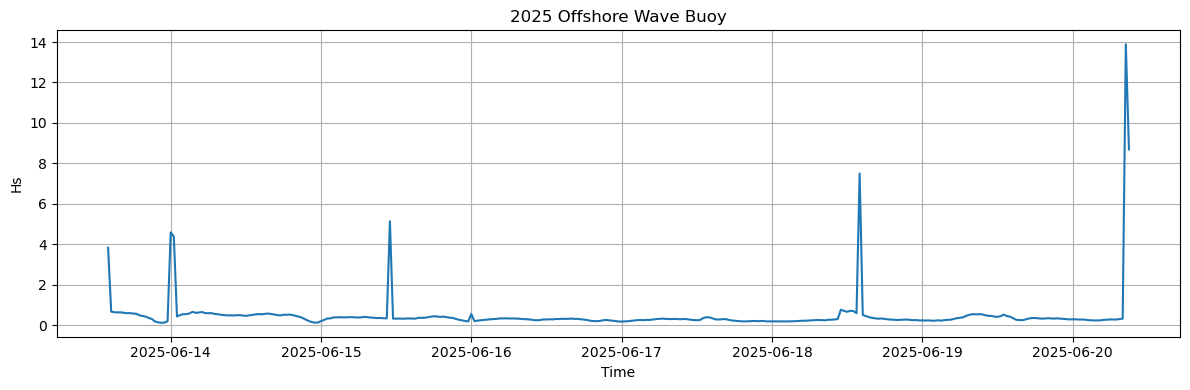

In [ ]:
def quick_plot(df, variable, title=""):

    print(df[variable].describe())

    plt.figure(figsize=(12, 4))
    plt.plot(df["Date_time"], df[variable])

    plt.xlabel("Time")
    plt.ylabel(variable)
    plt.title(title)
    plt.grid()

    plt.tight_layout()
    plt.show()

quick_plot(
    processed[2025]["buoy_wave"], 
    "Hs", 
    "2025 Offshore Wave Buoy"
)

# Nearshore vs Offshore

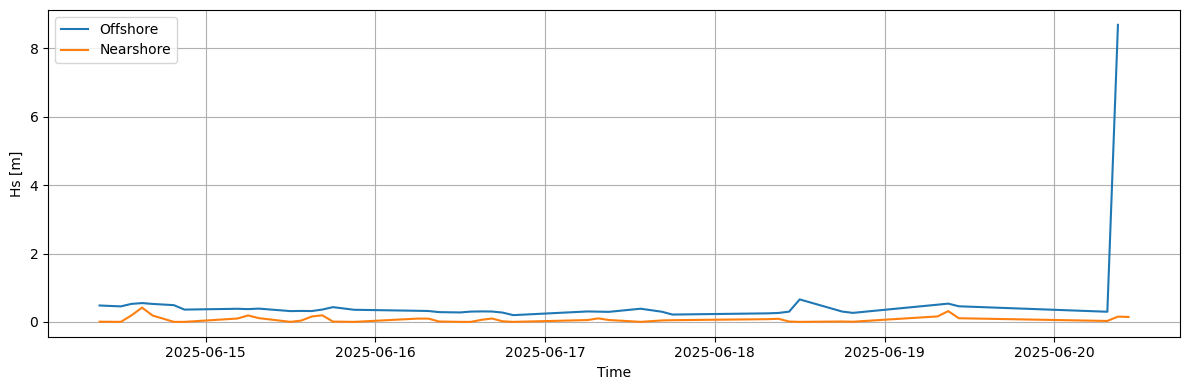

In [113]:
near_wave = processed[2025]["twr_wave"].loc[
    ~processed[2025]["twr_wave"]["dry_or_exposed"],
    ["Date_time", "Hs"]
].rename(columns={"Hs": "Hs_near"})


off_wave = processed[2025]["buoy_wave"].loc[
    ~processed[2025]["buoy_wave"]["QA_outlier"],
    ["Date_time", "Hs"]
].rename(columns={"Hs": "Hs_off"})


wave_compare_2025 = merge_nearest(
    near_wave,
    off_wave,
    tolerance="45min"
)

wave_compare_2025["Hs_ratio"] = (
    wave_compare_2025["Hs_near"]
    / wave_compare_2025["Hs_off"]
)

wave_compare_2025["Energy_ratio"] = (
    wave_compare_2025["Hs_ratio"]**2
)


plt.figure(figsize=(12, 4))

plt.plot(
    wave_compare_2025["Date_time"],
    wave_compare_2025["Hs_off"],
    label="Offshore"
)

plt.plot(
    wave_compare_2025["Date_time"],
    wave_compare_2025["Hs_near"],
    label="Nearshore"
)

plt.xlabel("Time")
plt.ylabel("Hs [m]")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# SSC Relationships

In [114]:
def plot_ssc_relationships(df, variables, labels, location):

    fig, axes = plt.subplots(1, len(variables), figsize=(15, 4))

    for ax, variable, label in zip(axes, variables, labels):

        ax.scatter(df[variable], df["SSC"])
        ax.set_xlabel(label)
        ax.set_ylabel("SSC [g/L]")
        ax.set_title(f"{location}: SSC vs {label}")
        ax.grid()

    plt.tight_layout()
    plt.show()


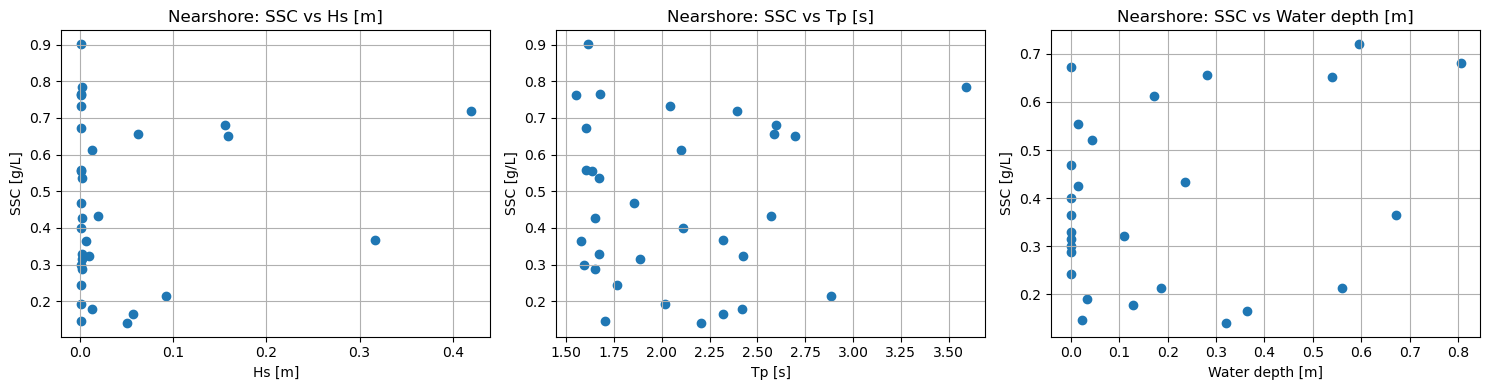

In [115]:
#nearshore 
plot_ssc_relationships(
    near_2025_ssc,
    ["Hs", "Tp", "Water_depth"],
    ["Hs [m]", "Tp [s]", "Water depth [m]"],
    "Nearshore"
)

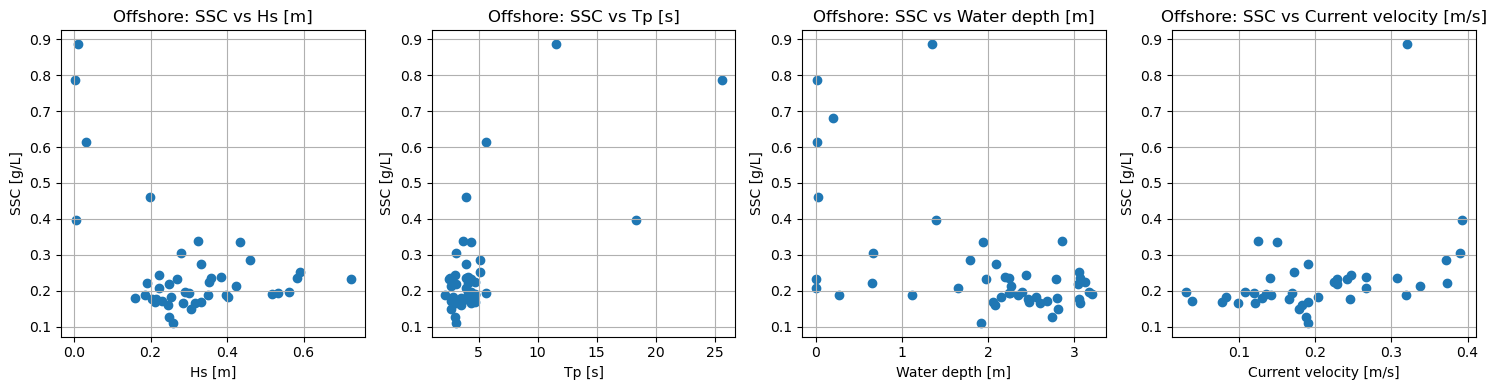

In [116]:
#offshore
plot_ssc_relationships(
    off_2025_ssc,
    ["Hs", "Tp", "Depth", "Current_velocity"],
    ["Hs [m]", "Tp [s]", "Water depth [m]", "Current velocity [m/s]"],
    "Offshore"
)

In [117]:
#correlations
near_corr = near_2025_ssc[
    ["SSC", "Hs", "Tp", "Water_depth"]
].corr()

off_corr = off_2025_ssc[
    ["SSC", "Hs", "Tp", "Depth", "Current_velocity"]
].corr()


print("Nearshore")
display(near_corr.round(2))

print("Offshore")
display(off_corr.round(2))

Nearshore


,SSC,Hs,Tp,Water_depth
SSC,1.00,0.14,0.06,0.29
Hs,0.14,1.00,0.38,0.81
Tp,0.06,0.38,1.00,0.78
Water_depth,0.29,0.81,0.78,1.00


Offshore


,SSC,Hs,Tp,Depth,Current_velocity
SSC,1.00,-0.47,0.70,-0.54,0.38
Hs,-0.47,1.00,-0.43,0.47,-0.23
Tp,0.70,-0.43,1.00,-0.40,0.34
Depth,-0.54,0.47,-0.40,1.00,-0.63
Current_velocity,0.38,-0.23,0.34,-0.63,1.00


# Tidal analysis - Welch Spectrum
This is mostly useful for tidal analysis, not so much for constructing a spectrum of the frequencies of waves in the area. This is because the sensors have a nyquist frequency that is too low to pick up the actual spectrum. Can find tides, but since the data colletion is only conducted for a week, it will not pick up on long term seaonal trends

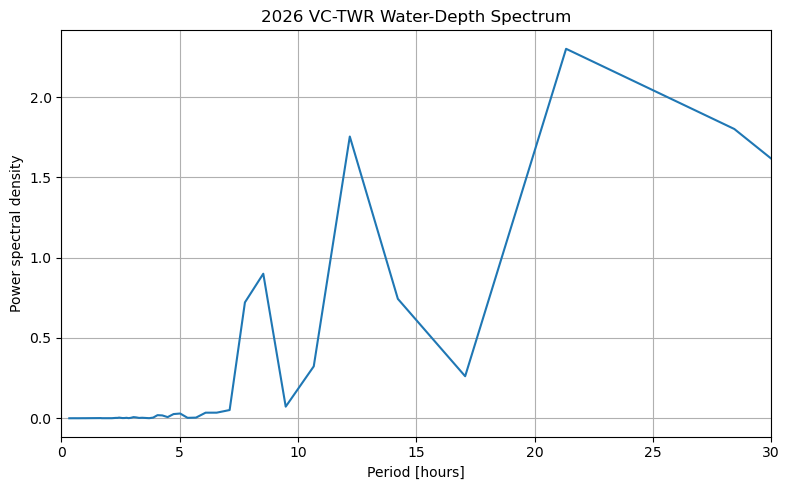

In [118]:
water = (
    processed[2026]["water_depth"]
    .dropna(subset=["Depth"])
    .sort_values("Date_time")
)

depth = water["Depth"].to_numpy()

# Determine sampling interval directly from the data
dt_seconds = (
    water["Date_time"]
    .diff()
    .dt.total_seconds()
    .median()
)

# Sampling frequency in measurements per hour
fs = 3600 / dt_seconds


# Welch power spectrum
f, Pxx = welch(
    depth,
    fs=fs,
    nperseg=min(512, len(depth)),
    detrend="constant"
)


# Remove zero frequency before converting to period
mask = f > 0

f = f[mask]
Pxx = Pxx[mask]

period_hours = 1 / f


# Sort periods for plotting
order = np.argsort(period_hours)

period_hours = period_hours[order]
Pxx = Pxx[order]


plt.figure(figsize=(8, 5))

plt.plot(period_hours, Pxx)

plt.xlabel("Period [hours]")
plt.ylabel("Power spectral density")
plt.title("2026 VC-TWR Water-Depth Spectrum")

plt.xlim(0, 30)
plt.grid()

plt.tight_layout()
plt.show()

# EXTRA, EXPAND, CHECK!

In [52]:
water_2026 = processed[2026]["water_depth"].copy()

twr_2026 = processed[2026]["twr_wave"].copy()


near_2026 = pd.merge(
    water_2026,
    twr_2026,
    on="Date_time",
    how="inner"
)

display(
    near_2026[
        [
            "Date_time",
            "Depth",
            "Hs",
            "H_max",
            "H_mean",
            "H_10",
            "Wave_energy"
        ]
    ].head()
)

,Date_time,Depth,Hs,H_max,H_mean,H_10,Wave_energy
0,2026-06-22 18:00:00,1.185,0.0013,0.0020,0.0008,0.0017,0.0034
1,2026-06-22 18:10:00,1.187,0.0019,0.0028,0.0009,0.0028,0.0042
2,2026-06-22 18:20:00,1.186,0.0012,0.0016,0.0007,0.0014,0.0016
3,2026-06-22 18:30:00,1.186,0.0012,0.0014,0.0009,0.0014,0.0014
4,2026-06-22 18:40:00,1.188,0.0028,0.0051,0.0016,0.0043,0.0114
